In [51]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import os
import sys
#sys.path.append('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search/')
sys.path.append('/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Job Search')
#print(os.getcwd())
#print(os.listdir("/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search"))
import Model_components as model
import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate 
import optimagic as om
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pandas as pd
import scipy.optimize as opt
from scipy.optimize import fsolve
from scipy.stats import beta
# from numba import njit, vectorize


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


### We define the parameters and institutions for the model

In [52]:
delta = 0.93
gamma = 0.9
eta = 1
k = 300
k1 = 300
k2 = 250
k3 = 200
q1 = 0.3
q2 = 0.3
lmbda = 4.9
N = 6

abar = [0, 1000]

n_a = 50
n_c = 100
T1 = 6
T2 = 18
T3 = 24
T = 44
b1= 222
b2 = 222
b3 = 114 
welfare = 90
w = 675
R = 0.01

htm = 1



In [53]:
params = np.array([delta, gamma, eta, k, lmbda, N])
params_multi = np.array([delta, gamma, eta, k1, k2, k3, q1, q2,lmbda, N])
institutions_pre = np.array([ n_a, n_c, T1, T2, T3, T, b1, b2, b3, welfare, w, R])
b1 = 342
b2 = 171
institutions_post = np.array([ n_a, n_c, T1, T2, T3, T, b1, b2, b3, welfare, w, R])

# Asset grid
a_grid = np.linspace(abar[0], abar[1], n_a)

# Scale asset grid to [0,1]
x = (a_grid - abar[0]) / (abar[1] - abar[0])

# Plausible right-skewed asset distribution
alpha = 1.5
beta_param = 4.0

weights = beta.pdf(x, alpha, beta_param)

# Normalize so weights sum to 1
weights = weights / weights.sum()

### Here we set the weights to either being right-skewed, such that the bulk of the mass is on low asset holders
### or it is a hand-to-mouth model. We define both alongside the parameters. 

In [89]:
if htm == 0: 

    a_grid = np.linspace(abar[0], abar[1], n_a)

    # Convert grid to [0,1]
    x = (a_grid - abar[0]) / (abar[1] - abar[0])

    # Bin boundaries halfway between grid points
    edges = np.empty(n_a + 1)
    edges[1:-1] = (x[:-1] + x[1:]) / 2
    edges[0] = 0
    edges[-1] = 1

    alpha = 1.5
    beta_param = 4.0

# Probability mass in each bin
    weights = np.diff(beta.cdf(edges, alpha, beta_param))

    weights /= weights.sum()

else: 
    weights = np.zeros(n_a)
    weights[0] = 1.0

print(weights)

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]


In [55]:
S, V_emp, V_unemp, c_emp, c_unemp, Vss_emp, Vss_uemp, css_emp, css_uemp, survival, benefits = model.SolveModel(params, institutions_pre, abar)

Optimal consumption of assets solved in 280 iterations, using 0.04641 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04419 seconds


In [56]:
#S, V_emp, V_unemp, c_emp, c_unemp, Vss_emp, Vss_uemp, css_emp, css_uemp, survival, benefits = model.SolveModel(delta, gamma, eta, k, lmbda, N abar, n_a, n_c, T1, T2, T3, T , b1, b2, b3, welfare, w, R)

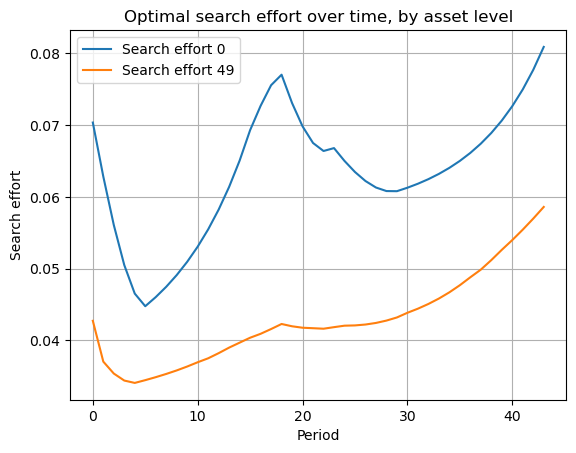

In [57]:
plt.plot(S[0,:-1], label="Search effort 0")
plt.plot(S[49,:-1], label="Search effort 49")
#plt.plot(S[10,:], label="Search")
plt.xlabel("Period")
plt.ylabel("Search effort")
plt.title("Optimal search effort over time, by asset level")
plt.legend()
plt.grid(True)
plt.show()

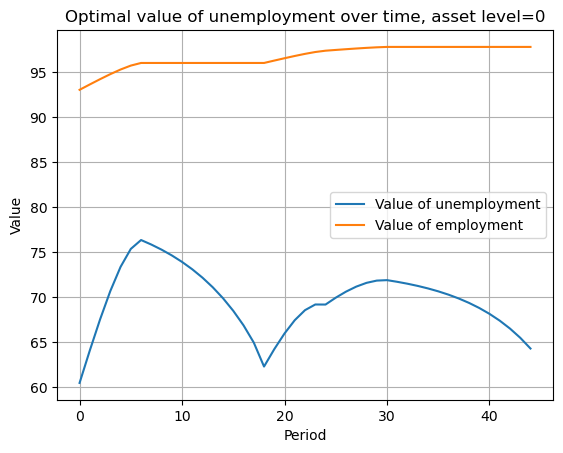

In [58]:
plt.plot(V_unemp[0,:], label="Value of unemployment")
plt.plot(V_emp[0,:], label="Value of employment")
#plt.plot(S[10,:], label="Search")
plt.xlabel("Period")
plt.ylabel("Value")
plt.title("Optimal value of unemployment over time, asset level=0")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
moments = model.simulate_moments(params, institutions_pre, institutions_post, abar, weights)
timevec = np.arange((len(moments))/2)*15 + 15

Optimal consumption of assets solved in 280 iterations, using 0.14705 seconds
Optimal consumption of assets solved in 275 iterations, using 0.1402 seconds
Optimal consumption of assets solved in 280 iterations, using 0.08544 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04613 seconds


In [60]:
# Create target (empirical moments) and covariance matrix
target, cov = model.matchingMoments()

# Create weighting function
W = np.linalg.inv(cov)



In [61]:
# Create SSE, distance measure
SSE = model.sse(params, target, W, institutions_pre, institutions_post, abar, weights)

Optimal consumption of assets solved in 280 iterations, using 0.4844 seconds
Optimal consumption of assets solved in 275 iterations, using 0.50028 seconds
Optimal consumption of assets solved in 280 iterations, using 0.43207 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04571 seconds


In [62]:
print(f'SSE (Goodness of Fit): {SSE}')

SSE (Goodness of Fit): 3730.7149033836504


In [63]:
def split_half(arr):
    mid = len(arr) // 2
    return arr[:mid], arr[mid:]

pre, post = split_half(moments)


emp_pre, emp_post = split_half(target)


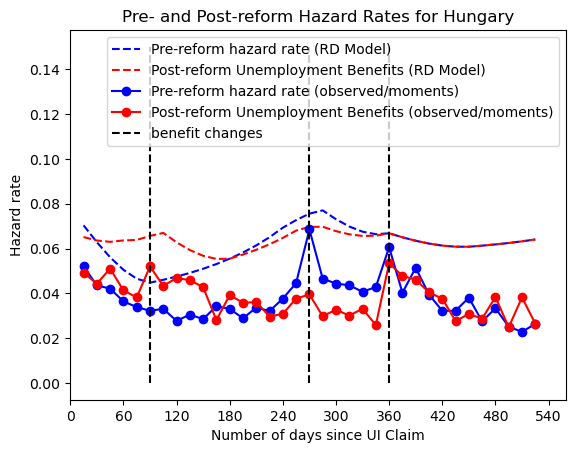

In [64]:
plt.plot(timevec, pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec, post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec, emp_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec, emp_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[6*15, 18*15, 24*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

In [65]:
fixed_params = params

In [66]:
sse1 = model.sse(fixed_params, target, W, institutions_pre, institutions_post, abar, weights)

Optimal consumption of assets solved in 280 iterations, using 0.15137 seconds
Optimal consumption of assets solved in 275 iterations, using 0.13849 seconds
Optimal consumption of assets solved in 280 iterations, using 0.047 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04588 seconds


In [67]:
params_full = pd.DataFrame(
    data={"value":[0.93, 0.9, 1, 300, 4.9, 6]},
    index=["delta", "gamma", "eta", "k", "lmbda", "N"]
    )

In [68]:
params_full

,value
delta,0.93
gamma,0.90
eta,1.00
k,300.00
lmbda,4.90
N,6.00


In [69]:
smm_object = model.smm(params_full.copy(), target, W, institutions_pre, institutions_post, abar, weights)

In [70]:
params2 = pd.DataFrame(
    data={"value":[0.3],
    "lower_bound" : [0.01],
    "upper_bound" : [2]},
    index=["gamma"],
    )

In [71]:
params2

,value,lower_bound,upper_bound
gamma,0.3,0.01,2


In [72]:
print(f'GMM SSE for gamma=0.3: {smm_object.sse(params2)}')

Optimal consumption of assets solved in 280 iterations, using 0.50218 seconds
Optimal consumption of assets solved in 275 iterations, using 0.44133 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04728 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04593 seconds
GMM SSE for gamma=0.3: 8743.660581029419


In [73]:
res = om.minimize(criterion=smm_object.sse, params=params2, algorithm='scipy_lbfgsb', )

Optimal consumption of assets solved in 280 iterations, using 0.04779 seconds
Optimal consumption of assets solved in 275 iterations, using 0.0453 seconds


/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:53: FutureWarning:

To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.



Optimal consumption of assets solved in 280 iterations, using 0.0492 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04797 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04861 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04766 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04908 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04646 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04921 seconds
Optimal consumption of assets solved in 275 iterations, using 0.0488 seconds
Optimal consumption of assets solved in 280 iterations, using 0.05187 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04864 seconds
Optimal consumption of assets solved in 280 iterations, using 0.06294 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04781 seconds
Optimal consumption of assets solved in 280 iterations, using 0.05

In [74]:
print(f'Optimized gamma parameter: {res.params}')
print(f'Objective function(SSE) at optimized gamma (minimum): {res.criterion}')

Optimized gamma parameter:           value  lower_bound  upper_bound
gamma  0.726254         0.01            2
Objective function(SSE) at optimized gamma (minimum): 342.64914320426396


/opt/anaconda3/lib/python3.12/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning:

The criterion attribute is deprecated. Use the fun attribute instead.



In [75]:
smm_object.params_full.update(res.params)
print(smm_object.params_full)

            value
delta    0.930000
gamma    0.726254
eta      1.000000
k      300.000000
lmbda    4.900000
N        6.000000


In [76]:
params_rd = pd.DataFrame(
    data={"value":params[:5],
    "lower_bound" : [0.01, 1e-2, 0.01, 1e-5, 0.01],
    "upper_bound" : [0.95, 2, 15, 2000, 15]},
    index=["delta", "gamma", "eta", "k", "lmbda"],
    )

In [77]:
params_rd

,value,lower_bound,upper_bound
delta,0.93,0.01000,0.95
gamma,0.90,0.01000,2.00
eta,1.00,0.01000,15.00
k,300.00,0.00001,2000.00
lmbda,4.90,0.01000,15.00


In [78]:
print(f'SMM SSE for params_rd: {smm_object.sse(params_rd)}')


Optimal consumption of assets solved in 280 iterations, using 0.05321 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04743 seconds
Optimal consumption of assets solved in 280 iterations, using 0.05029 seconds
Optimal consumption of assets solved in 275 iterations, using 0.0481 seconds
SMM SSE for params_rd: 3730.7149033836504


## Her kan vi køre forskellige estimationsmetoder

In [79]:

# Here we do it using a normal weighting matrix
#res_rd = om.minimize(criterion=smm_object.sse, params=params_rd, algorithm='scipy_lbfgsb', )

# here below is a Cholesky minimized weighting matrix. This is faster. 
res_rd = om.minimize(criterion=smm_object.criterion, params=params_rd, algorithm='scipy_ls_trf', )

res_bobyqa = om.minimize(
    fun=smm_object.sse,
    params=params_rd,
    algorithm="nlopt_bobyqa",
)

/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:53: FutureWarning:

To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.



Optimal consumption of assets solved in 280 iterations, using 0.0478 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04451 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04705 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04571 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04749 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04653 seconds


/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:333: FutureWarning:

Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html



Optimal consumption of assets solved in 280 iterations, using 0.04854 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04542 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04738 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04605 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04727 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04504 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04661 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04495 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04639 seconds
Optimal consumption of assets solved in 275 iterations, using 0.0451 seconds
Optimal consumption of assets solved in 280 iterations, using 0.04677 seconds
Optimal consumption of assets solved in 275 iterations, using 0.04529 seconds
Optimal consumption of assets solved in 280 iterations, using 0.0

In [80]:
print(f'Optimized parameters: {res_rd.params}')
print(f'Objective function(SSE) at optimized parameters: {res_rd.criterion}')

Optimized parameters:              value  lower_bound  upper_bound
delta     0.850423      0.01000         0.95
gamma     1.354274      0.01000         2.00
eta       0.496842      0.01000        15.00
k      1246.046496      0.00001      2000.00
lmbda    14.985472      0.01000        15.00
Objective function(SSE) at optimized parameters: 236.42057944547923


/opt/anaconda3/lib/python3.12/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning:

The criterion attribute is deprecated. Use the fun attribute instead.



In [81]:
fig = om.criterion_plot(res_rd)
fig

In [82]:
res_rd.params

,value,lower_bound,upper_bound
delta,0.850423,0.01000,0.95
gamma,1.354274,0.01000,2.00
eta,0.496842,0.01000,15.00
k,1246.046496,0.00001,2000.00
lmbda,14.985472,0.01000,15.00


In [83]:
opt =res_rd.params

In [84]:
#insert params_rd on first 5 columns of params
params_opt = params
params_opt[:5] = res_rd.params['value']
params_opt

array([8.50422736e-01, 1.35427412e+00, 4.96842321e-01, 1.24604650e+03,
       1.49854724e+01, 6.00000000e+00])

In [85]:
moments = model.simulate_moments(params_opt, institutions_pre, institutions_post, abar, weights)
opt_pre, opt_post = split_half(moments)


opt_emp_pre, opt_emp_post = split_half(target)




Optimal consumption of assets solved in 125 iterations, using 0.0225 seconds
Optimal consumption of assets solved in 123 iterations, using 0.0203 seconds
Optimal consumption of assets solved in 125 iterations, using 0.02155 seconds
Optimal consumption of assets solved in 123 iterations, using 0.0214 seconds


In [86]:
sse_opt = model.sse(params_opt, target, W, institutions_pre, institutions_post, abar, weights)
print(f'SSE (Goodness of Fit) for optimized parameters: {sse_opt}')

Optimal consumption of assets solved in 125 iterations, using 0.02241 seconds
Optimal consumption of assets solved in 123 iterations, using 0.0204 seconds
Optimal consumption of assets solved in 125 iterations, using 0.02113 seconds
Optimal consumption of assets solved in 123 iterations, using 0.02045 seconds
SSE (Goodness of Fit) for optimized parameters: 236.42057944547923


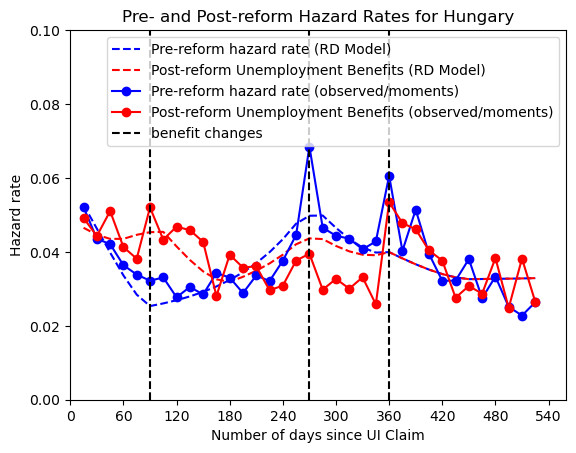

In [87]:
plt.plot(timevec, opt_pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec, opt_post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec, opt_emp_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec, opt_emp_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.ylim(0, 0.1) # set x-axis limits to first and last element in timevec
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[6*15, 18*15, 24*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

In [88]:
asset_indices = [0, 5, 10, 25, 50, 75, 99]

for i in asset_indices:
    plt.plot(
        timevec_H,
        S_pre[i, :35],
        label=f"A = {a_grid[i]:.0f}"
    )

plt.xlabel("Days since UI claim")
plt.ylabel("Search effort")
plt.legend()
plt.show()

NameError: name 'timevec_H' is not defined